In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
# import seaborn as sns
import os
import sys
import requests
import torch
from torch import nn, distributions
from scipy.spatial.distance import cdist
from scipy.stats import norm, multivariate_normal
import GPyOpt
import GPy
import math
import rasterio
from rasterio.warp import transform
import pickle
from util import BO_results, make_equal_area_box, query, plot_simple_regret
from locations import peaks



In [2]:
def plot_kernel_landscapes2(all_results, peak_name, trial_idx=0):
    """
    Show the GP predicted surface for each kernel side by side.
    Uses the saved X and Y from a single trial to refit the GP.

    trial_idx: which seed/trial to visualize (default first)
    """
    kernel_names = list(all_results[peak_name].keys())
    n_kernels = len(kernel_names)

    fig, axes = plt.subplots(1, n_kernels, figsize=(6 * n_kernels, 5))
    if n_kernels == 1:
        axes = [axes]

    for ax, kernel_name in zip(axes, kernel_names):
        trial = all_results[peak_name][kernel_name][trial_idx]
        X = trial["X"]
        Y = trial["Y"]

        # Refit GP from saved data
        kernel_map = {
            "RBF": GPy.kern.RBF(input_dim=2),
            "Matern32": GPy.kern.Matern32(input_dim=2),
            "Matern52": GPy.kern.Matern52(input_dim=2),
        "Composite": GPy.kern.Matern52(input_dim=2)+GPy.kern.RBF(input_dim=2),
        }
        kern = kernel_map[kernel_name].copy()
        gp = GPy.models.GPRegression(X, Y, kern,noise_var=noise_var)
        gp.optimize_restarts(num_restarts=3, verbose=False)

        # Build prediction grid
        lon_min, lon_max = X[:, 0].min(), X[:, 0].max()
        lat_min, lat_max = X[:, 1].min(), X[:, 1].max()
        # Pad slightly beyond sampled points
        lon_pad = (lon_max - lon_min) * 0.05
        lat_pad = (lat_max - lat_min) * 0.05

        grid_x = np.linspace(lon_min - lon_pad, lon_max + lon_pad, 100)
        grid_y = np.linspace(lat_min - lat_pad, lat_max + lat_pad, 100)
        X1, X2 = np.meshgrid(grid_x, grid_y)
        X_grid = np.column_stack([X1.ravel(), X2.ravel()])

        mean, var = gp.predict(X_grid)
        mean = -mean.reshape(100, 100)  # negate since we minimized -elevation

        extent = [grid_x[0], grid_x[-1], grid_y[0], grid_y[-1]]
        im = ax.imshow(
            mean, cmap="terrain", origin="lower", extent=extent, aspect="auto"
        )
        ax.scatter(
            X[:, 0],
            X[:, 1],
            c="red",
            s=10,
            zorder=5,
            edgecolors="black",
            linewidths=0.5,
        )
        ax.set_title(f"{kernel_name}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.colorbar(im, ax=ax, label="Elevation (m)")

    fig.suptitle(
        f"GP Predicted Surfaces — {peak_name}", fontsize=14
    )
    plt.tight_layout()
    plt.show()

In [3]:
all_results = pickle.load(open('bo_results3.pkl', 'rb'))

In [4]:
peakList = ['south_downs', 'everest', 'olympus', 'piton_neiges', 'fuji']
kernels = {
    "RBF": GPy.kern.RBF(input_dim=2),
    "Matern32": GPy.kern.Matern32(input_dim=2),
    "Matern52": GPy.kern.Matern52(input_dim=2),
    "Composite": GPy.kern.Matern52(input_dim=2)+GPy.kern.RBF(input_dim=2),
}


In [5]:
rows = []
for kernel_name in kernels:
    row = {"Kernel": kernel_name}
    for peak_name in peakList:
        trials = all_results[peak_name][kernel_name]
        # final simple regret = last value in each trial's simple_regret array
        final_regrets = [t["simple_regret"][-1] for t in trials]
        mean_r = np.mean(final_regrets)
        std_r = np.std(final_regrets)
        row[peak_name] = f"{mean_r:.1f} +- {std_r}"
    rows.append(row)

df_regret = pd.DataFrame(rows).set_index("Kernel")
df_regret

,south_downs,everest,olympus,piton_neiges,fuji
Kernel,,,,,
RBF,3.0 +- 0.0,22.0 +- 0.0,54.0 +- 0.0,33.0 +- 0.0,13.0 +- 0.0
Matern32,26.0 +- 0.0,-1.0 +- 0.0,1.0 +- 0.0,3.0 +- 0.0,6.0 +- 0.0
Matern52,4.0 +- 0.0,0.0 +- 0.0,66.0 +- 0.0,1.0 +- 0.0,37.0 +- 0.0
Composite,-1.0 +- 0.0,-1.0 +- 0.0,0.0 +- 0.0,3.0 +- 0.0,0.0 +- 0.0


In [6]:
noise_var = 1e-3  # small noise for numerical stability

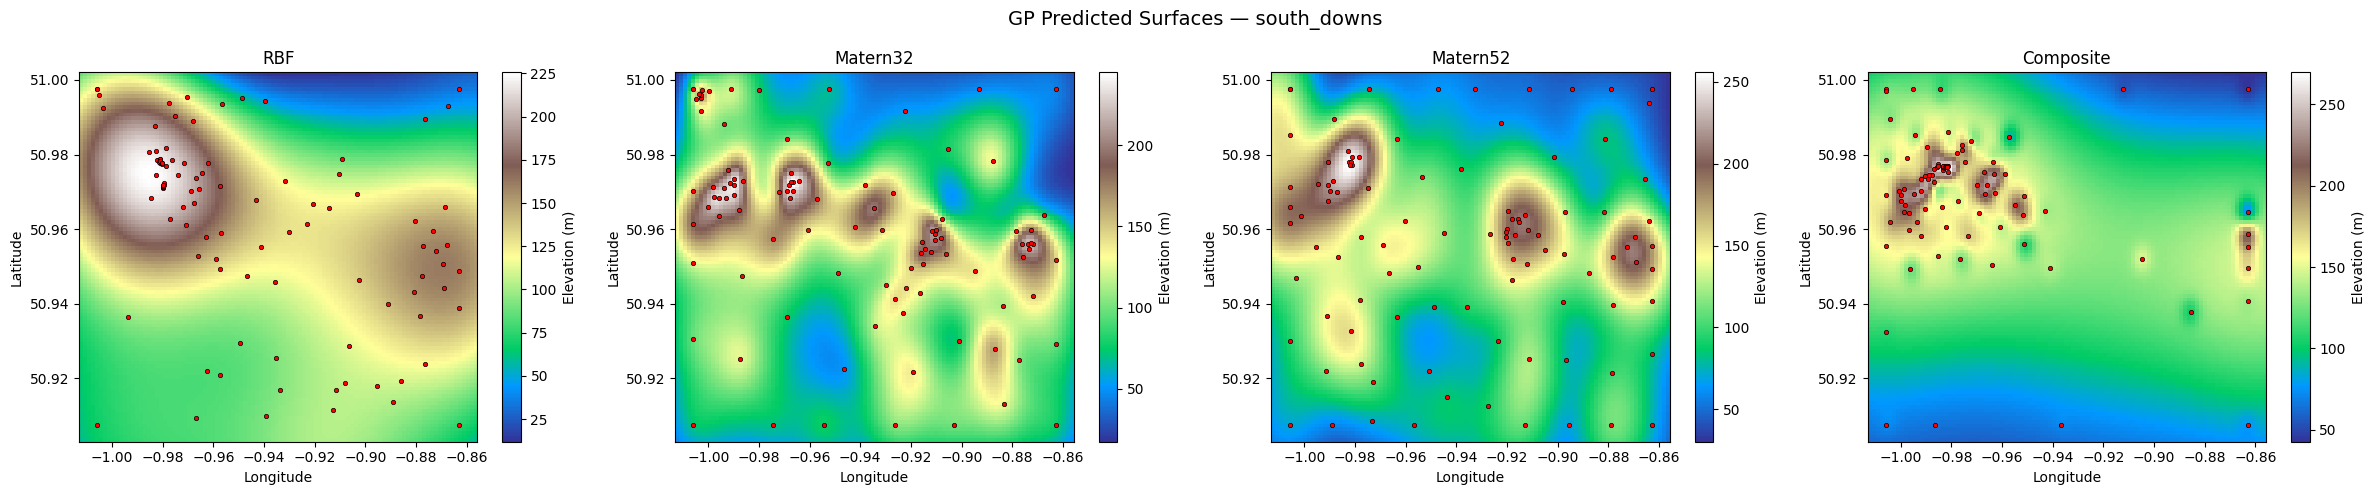

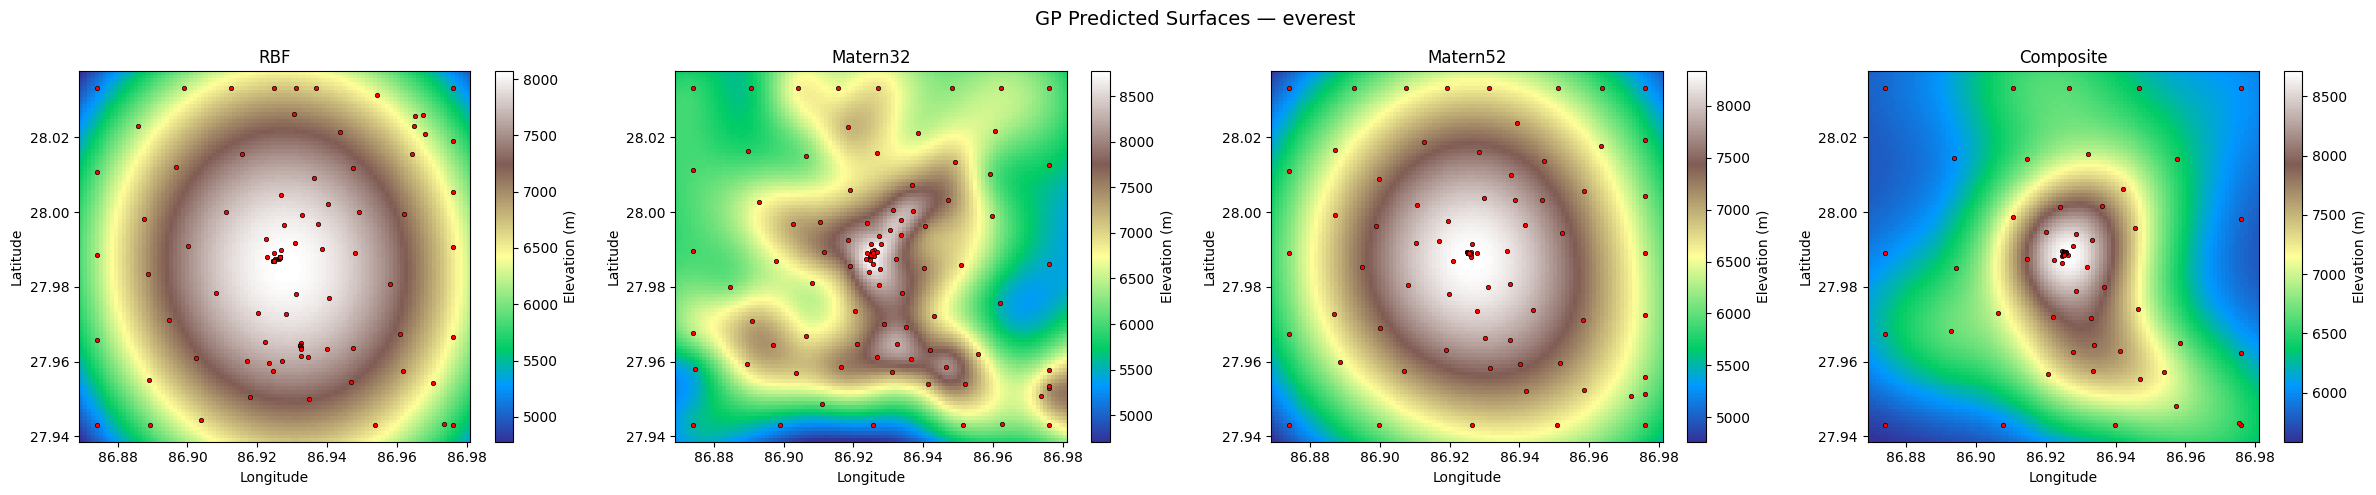

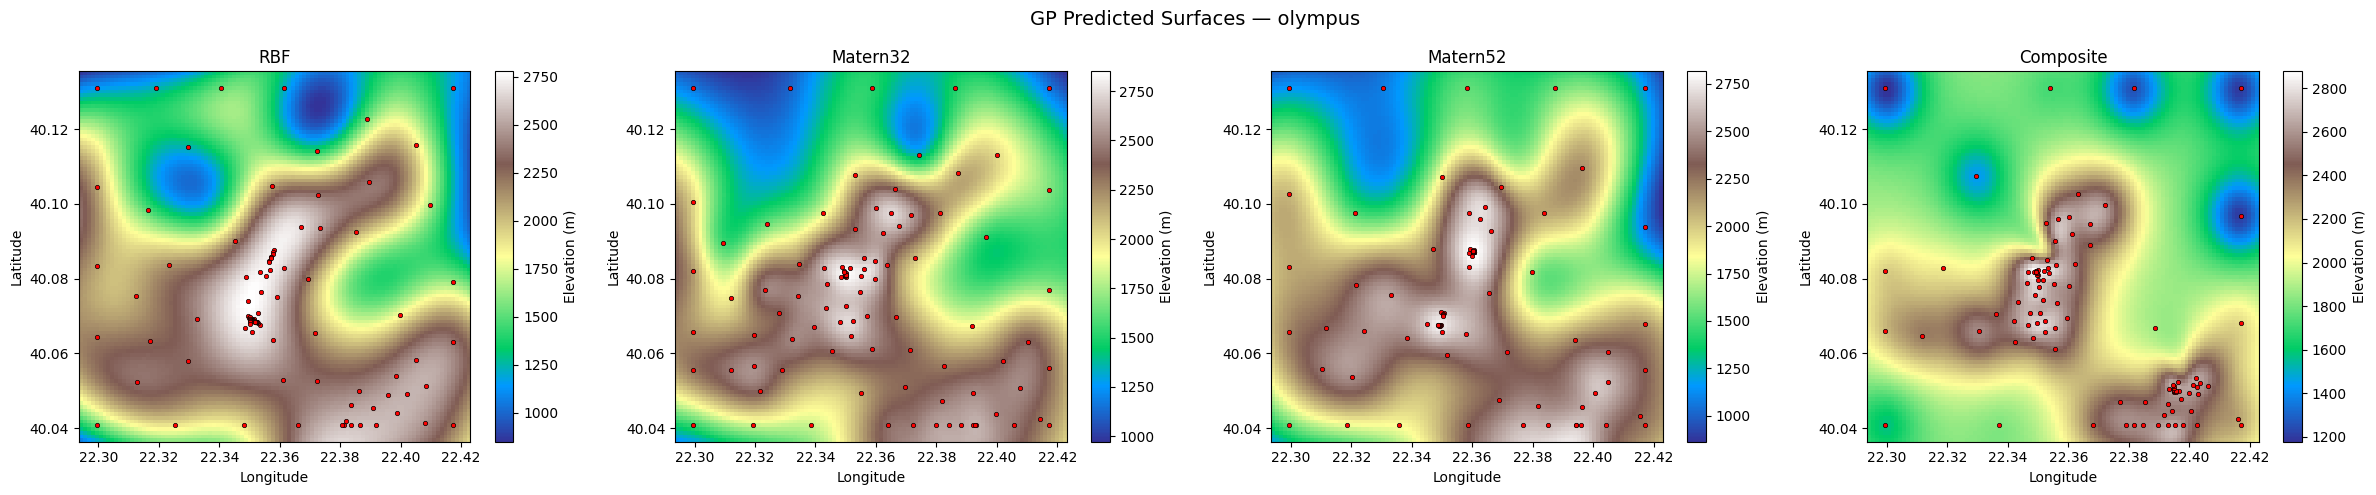

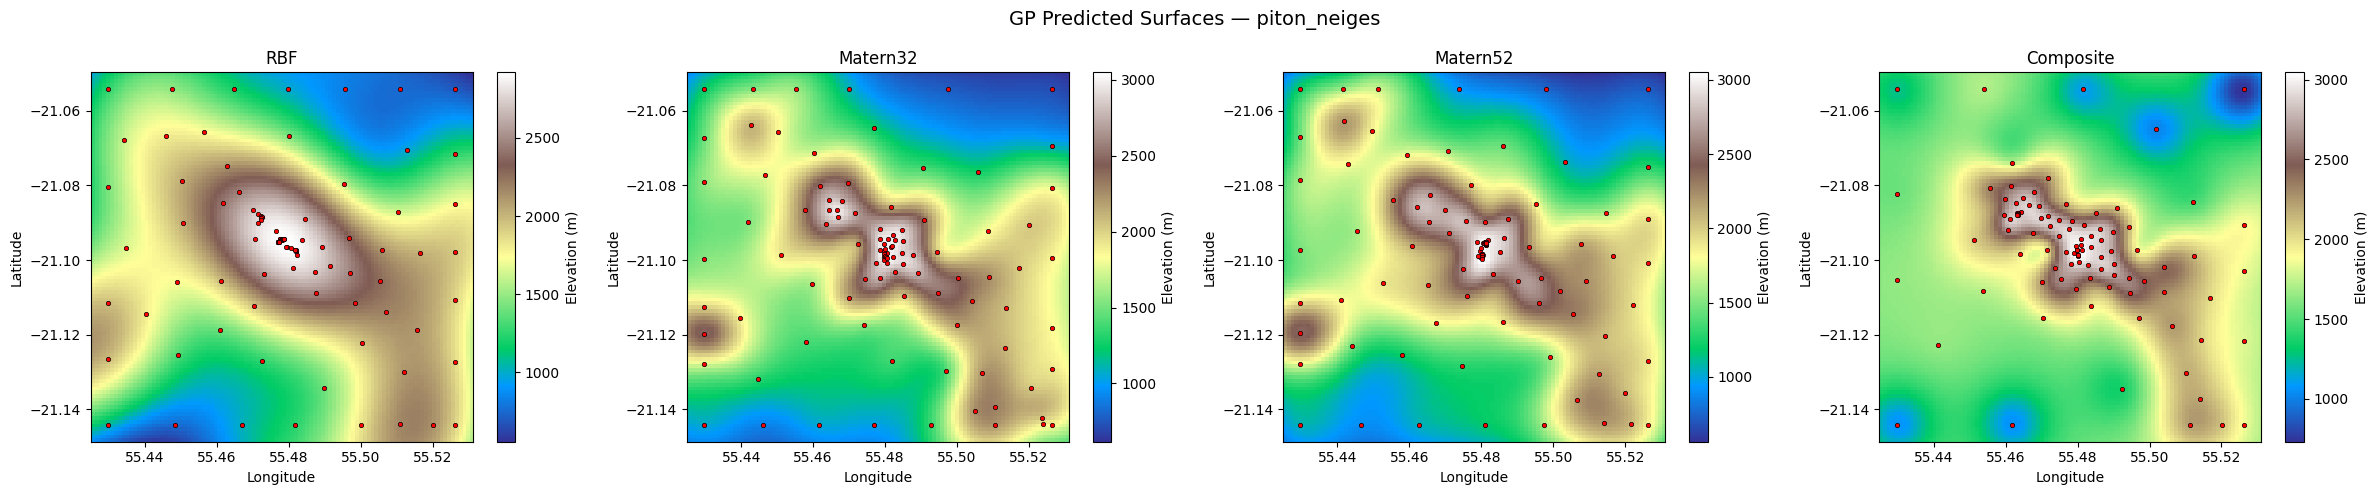

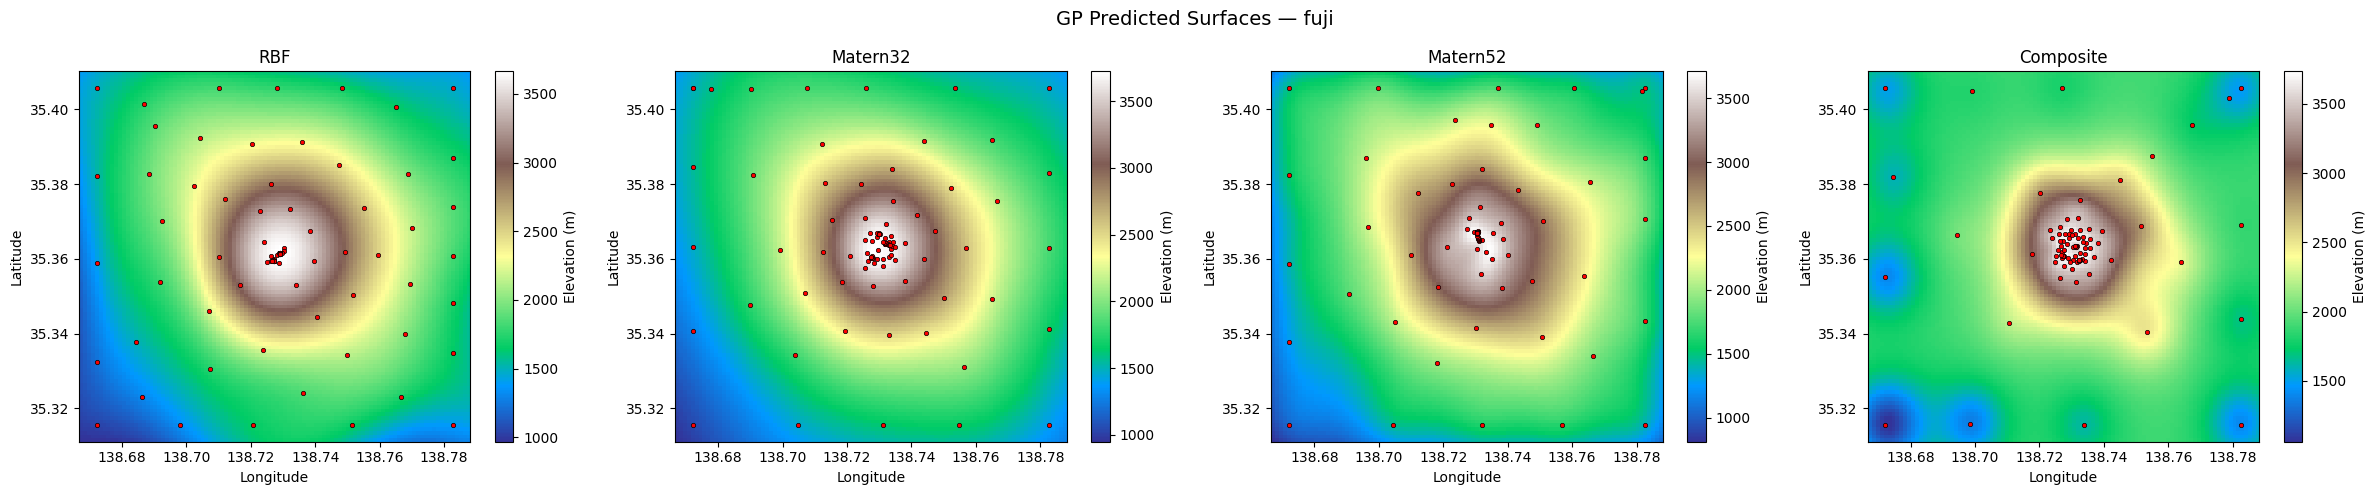

In [7]:
for peak_name in peakList:
    
    plot_kernel_landscapes2(all_results, peak_name)